<a href="https://colab.research.google.com/github/TediBalint/AI-Jegyzetek/blob/master/AlgoPro/AlgoPro%20NLP%20POS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import urllib.request
import os
import re
from collections import Counter
import matplotlib.pyplot as plt

Dataset: **English Web Treebank** (EWT) from the Universal Dependencies project. ~16,600 sentences from blogs, emails, newsgroups, reviews and Q&A sites. The data uses **Universal POS tags** (UPOS):

| Tag   | Meaning           | Example        |
|-------|-------------------|----------------|
| NOUN  | noun              | *cat, idea*    |
| VERB  | verb              | *run, think*   |
| ADJ   | adjective         | *big, green*   |
| ADV   | adverb            | *very, here*   |
| DET   | determiner        | *the, a, this* |
| ADP   | adposition (prep) | *in, on, of*   |
| PRON  | pronoun           | *he, she, it*  |
| AUX   | auxiliary verb    | *is, have, will* |
| PROPN | proper noun       | *London, Mary* |
| CCONJ | coord. conj.      | *and, but, or* |
| SCONJ | subord. conj.     | *if, that, when* |
| PART  | particle          | *not, to, 's*  |
| NUM   | numeral           | *1, two, 3.5*  |
| PUNCT | punctuation       | *. , ! ?*      |
| INTJ  | interjection      | *oh, wow, yes* |
| SYM   | symbol            | *$, %, @*      |
| X     | other             | *asdf, lol*    |

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

BASE_URL = "https://raw.githubusercontent.com/UniversalDependencies/UD_English-EWT/master"
urls = {
    "train": f"{BASE_URL}/en_ewt-ud-train.conllu",
    "dev":   f"{BASE_URL}/en_ewt-ud-dev.conllu",
    "test":  f"{BASE_URL}/en_ewt-ud-test.conllu",
}

os.makedirs("ud_ewt", exist_ok=True)
for split, url in urls.items():
    path = f"ud_ewt/{split}.conllu"
    if not os.path.exists(path):
        print(f"Downloading {split}...")
        urllib.request.urlretrieve(url, path)

In [3]:
def read_conllu(filepath):
    sentences = []
    current = []

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line == '':
                if current:
                    sentences.append(current)
                    current = []
            elif line.startswith('#'):
                continue
            else:
                fields = line.split('\t')
                if len(fields) >= 4:
                    token_id = fields[0]
                    # Skip multi-word token lines (e.g., "1-2")
                    if '-' in token_id or '.' in token_id:
                        continue
                    token = fields[1]
                    upos = fields[3]
                    current.append((token, upos))
        if current:
            sentences.append(current)

    return sentences

train_sentences = read_conllu("ud_ewt/train.conllu")
val_sentences = read_conllu("ud_ewt/dev.conllu")
test_sentences = read_conllu("ud_ewt/test.conllu")

print(f"Train:      {len(train_sentences):>6,} sentences, {sum(len(s) for s in train_sentences):>7,} tokens")
print(f"Validation: {len(val_sentences):>6,} sentences, {sum(len(s) for s in val_sentences):>7,} tokens")
print(f"Test:       {len(test_sentences):>6,} sentences, {sum(len(s) for s in test_sentences):>7,} tokens")

Train:      12,544 sentences, 204,578 tokens
Validation:  2,001 sentences,  25,148 tokens
Test:        2,077 sentences,  25,094 tokens


In [4]:
for i in range(3):
    print(f"\nExample {i+1}:")
    for token, tag in train_sentences[i]:
        print(f"  {token:20s} {tag}")


Example 1:
  Al                   PROPN
  -                    PUNCT
  Zaman                PROPN
  :                    PUNCT
  American             ADJ
  forces               NOUN
  killed               VERB
  Shaikh               PROPN
  Abdullah             PROPN
  al                   PROPN
  -                    PUNCT
  Ani                  PROPN
  ,                    PUNCT
  the                  DET
  preacher             NOUN
  at                   ADP
  the                  DET
  mosque               NOUN
  in                   ADP
  the                  DET
  town                 NOUN
  of                   ADP
  Qaim                 PROPN
  ,                    PUNCT
  near                 ADP
  the                  DET
  Syrian               ADJ
  border               NOUN
  .                    PUNCT

Example 2:
  [                    PUNCT
  This                 DET
  killing              NOUN
  of                   ADP
  a                    DET
  respected            

In [5]:
tag_counter = Counter(tag for sent in train_sentences for _, tag in sent)
all_tags = set(tag_counter)

tag_names = sorted(all_tags)
tag2idx = {tag: idx for idx, tag in enumerate(tag_names)}
idx2tag = {idx: tag for tag, idx in tag2idx.items()}
NUM_TAGS = len(tag_names)

print(f"Number of POS tags: {NUM_TAGS}")
print(f"\nTag distribution in training data:")
total_tokens = sum(tag_counter.values())
for tag, count in tag_counter.most_common():
    print(f"  {tag:6s}  {count:>6,}  ({count/total_tokens*100:5.1f}%)")

Number of POS tags: 17

Tag distribution in training data:
  NOUN    34,751  ( 17.0%)
  PUNCT   23,596  ( 11.5%)
  VERB    22,576  ( 11.0%)
  PRON    18,678  (  9.1%)
  ADP     17,714  (  8.7%)
  DET     16,299  (  8.0%)
  ADJ     13,136  (  6.4%)
  AUX     12,815  (  6.3%)
  PROPN   12,620  (  6.2%)
  ADV     10,172  (  5.0%)
  CCONJ    6,687  (  3.3%)
  PART     5,748  (  2.8%)
  NUM      4,126  (  2.0%)
  SCONJ    3,819  (  1.9%)
  SYM        746  (  0.4%)
  INTJ       695  (  0.3%)
  X          400  (  0.2%)


In [6]:
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
PAD_IDX = 0
UNK_IDX = 1

# build word vocabulary (lowercase)
word_counts = Counter([w.lower() for sent in train_sentences for w, _ in sent])

# keep words that appear at least twice
MIN_FREQ = 2
vocab_words = [w for w in word_counts.keys() if word_counts[w] >= MIN_FREQ]
word2idx = {vocab_words[i]:i for i in range(len(vocab_words))}
VOCAB_SIZE = len(word2idx)

# build suffix vocabulary (last 3 chars)
suffix_counts = Counter([w[len(w)-3:].lower() for w in vocab_words])

suffix_vocab = list(suffix_counts.keys())
suffix2idx = {suffix_vocab[i]:i for i in range(len(suffix_vocab))}
SUFFIX_VOCAB_SIZE = len(suffix_vocab)

print(f"Word vocabulary size:   {VOCAB_SIZE:,}")
print(f"Suffix vocabulary size: {SUFFIX_VOCAB_SIZE:,}")

Word vocabulary size:   8,865
Suffix vocabulary size: 1,838


In [7]:
# case feature: encode capitalization pattern
# 0 = pad, 1 = lowercase, 2 = UPPERCASE, 3 = Titlecase, 4 = other
def get_case_id(token):
    if token == PAD_TOKEN:
      return 0
    if token.islower():
      return 1
    elif token.isupper():
      return 2
    elif token.istitle():
      return 3
    else:
      return 4

NUM_CASE_FEATURES = 5  # 0-4

def get_suffix_id(token):
  return suffix2idx.get(token[len(token)-3:].lower(), UNK_IDX)

# test
for word in ["running", "HELLO", "London", "123", "quickly"]:
    print(f"  {word:12s}  case={get_case_id(word)}  suffix='{word[-3:].lower()}'  suffix_id={get_suffix_id(word)}")

  running       case=1  suffix='ing'  suffix_id=23
  HELLO         case=2  suffix='llo'  suffix_id=1140
  London        case=3  suffix='don'  suffix_id=652
  123           case=4  suffix='123'  suffix_id=1
  quickly       case=1  suffix='kly'  suffix_id=475


In [8]:
class POSDataset(Dataset):
    """Converts (token, tag) sentences into tensors."""
    def __init__(self, sentences, word2idx, suffix2idx, tag2idx):
        self.data = []
        for sent in sentences:
            tokens = [t for t, _ in sent]
            tags = [tag for _, tag in sent]

            word_ids = [word2idx.get(t.lower(), UNK_IDX) for t in tokens]
            case_ids = [get_case_id(t) for t in tokens]
            suf_ids = [get_suffix_id(t) for t in tokens]
            tag_ids = [tag2idx[tag] for tag in tags]

            self.data.append({
                "word_ids": torch.tensor(word_ids, dtype=torch.long),
                "case_ids": torch.tensor(case_ids, dtype=torch.long),
                "suffix_ids": torch.tensor(suf_ids, dtype=torch.long),
                "tags": torch.tensor(tag_ids, dtype=torch.long),
                "tokens": tokens,
            })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [9]:
def collate_fn(batch):
    """Pad variable-length sequences and create masks."""
    word_ids = pad_sequence([x["word_ids"] for x in batch], batch_first=True, padding_value=PAD_IDX)
    case_ids = pad_sequence([x["case_ids"] for x in batch], batch_first=True, padding_value=0)
    suffix_ids = pad_sequence([x["suffix_ids"] for x in batch], batch_first=True, padding_value=PAD_IDX)
    tags = pad_sequence([x["tags"] for x in batch], batch_first=True, padding_value=-100)
    mask = (word_ids != PAD_IDX)
    tokens = [x["tokens"] for x in batch]

    return {
        "word_ids": word_ids,
        "case_ids": case_ids,
        "suffix_ids": suffix_ids,
        "tags": tags,
        "mask": mask,
        "tokens": tokens,
    }

In [10]:
BATCH_SIZE = 64

train_dataset = POSDataset(train_sentences, word2idx, suffix2idx, tag2idx)
val_dataset = POSDataset(val_sentences, word2idx, suffix2idx, tag2idx)
test_dataset = POSDataset(test_sentences, word2idx, suffix2idx, tag2idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# Verify
batch = next(iter(train_loader))
print(f"Batch shapes:")
print(f"  word_ids:   {batch['word_ids'].shape}")
print(f"  case_ids:   {batch['case_ids'].shape}")
print(f"  suffix_ids: {batch['suffix_ids'].shape}")
print(f"  tags:       {batch['tags'].shape}")
print(f"  mask:       {batch['mask'].shape}")

Batch shapes:
  word_ids:   torch.Size([64, 46])
  case_ids:   torch.Size([64, 46])
  suffix_ids: torch.Size([64, 46])
  tags:       torch.Size([64, 46])
  mask:       torch.Size([64, 46])


In [11]:
class BiLSTM_POS(nn.Module):
    def __init__(self, vocab_size, suffix_vocab_size, num_tags,
                 word_embed_dim, case_embed_dim, suffix_embed_dim,
                 hidden_dim, num_layers, dropout=0.5):
        super().__init__()
        lstm_in_size = word_embed_dim + case_embed_dim + suffix_embed_dim
        self.word_embedding = nn.Embedding(vocab_size, word_embed_dim)
        self.case_embedding = nn.Embedding(5, case_embed_dim)
        self.suffix_embedding = nn.Embedding(suffix_vocab_size, suffix_embed_dim)

        self.lstm = nn.LSTM(lstm_in_size, hidden_dim, num_layers, batch_first=True, bidirectional=True)

        self.dropout = nn.Dropout(p=dropout)
        # hidden_dim * 2 because bidirectional
        self.fc = nn.Linear(hidden_dim*2, num_tags)

    def forward(self, word_ids, case_ids, suffix_ids):
        word_emb = self.word_embedding(word_ids)
        case_emb = self.case_embedding(case_ids)
        suffix_emb = self.suffix_embedding(suffix_ids)
        z, _ = self.lstm(torch.cat([word_emb, case_emb, suffix_emb], -1))
        return self.fc(self.dropout(z))

In [12]:
WORD_EMBED_DIM = 100
CASE_EMBED_DIM = 16
SUFFIX_EMBED_DIM = 32
HIDDEN_DIM = 128
NUM_LAYERS = 2
DROPOUT = 0.5
model = BiLSTM_POS(
    vocab_size=VOCAB_SIZE,
    suffix_vocab_size=SUFFIX_VOCAB_SIZE,
    num_tags=NUM_TAGS,
    word_embed_dim=WORD_EMBED_DIM,
    case_embed_dim=CASE_EMBED_DIM,
    suffix_embed_dim=SUFFIX_EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(device)

In [13]:
batch =next(iter(train_loader))
word_ids = batch["word_ids"].to(device)
case_ids = batch["case_ids"].to(device)
suffix_ids = batch["suffix_ids"].to(device)
tags = batch["tags"].to(device)
mask = batch["mask"].to(device)
model(word_ids, case_ids, suffix_ids).shape

torch.Size([64, 54, 17])

In [14]:
LEARNING_RATE = 0.002
NUM_EPOCHS = 30
CLIP_NORM = 5.0

criterion = nn.CrossEntropyLoss(ignore_index=-100)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [15]:
def train_epoch(model, loader, criterion, optimizer, clip_norm):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in loader:
        word_ids = batch["word_ids"].to(device)
        case_ids = batch["case_ids"].to(device)
        suffix_ids = batch["suffix_ids"].to(device)
        tags = batch["tags"].to(device)
        mask = batch["mask"].to(device)

        logits = model(word_ids, case_ids, suffix_ids)
        loss = criterion(logits.reshape(-1, NUM_TAGS), tags.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_norm)
        optimizer.step()
        preds = logits.argmax(dim=-1)
        correct += ((preds == tags) & mask).sum().item()
        n = mask.sum().item()
        total_loss += loss.item() * n
        total += n

    return total_loss / total, correct / total

In [16]:
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            word_ids = batch["word_ids"].to(device)
            case_ids = batch["case_ids"].to(device)
            suffix_ids = batch["suffix_ids"].to(device)
            tags = batch["tags"].to(device)
            mask = batch["mask"].to(device)

            logits = model(word_ids, case_ids, suffix_ids)
            loss = criterion(logits.reshape(-1, NUM_TAGS), tags.reshape(-1))

            preds = logits.argmax(dim=-1)
            correct += ((preds == tags) & mask).sum().item()
            n = mask.sum().item()
            total_loss += loss.item() * n
            total += n

            # collect for per-tag analysis
            for i in range(preds.size(0)):
                length = mask[i].sum().item()
                all_preds.extend(preds[i, :length].cpu().tolist())
                all_labels.extend(tags[i, :length].cpu().tolist())

    return total_loss / total, correct / total, all_preds, all_labels

In [17]:
print(f"{'Epoch':>5} | {'Tr Loss':>8} | {'Tr Acc':>8} | {'Val Loss':>8} | {'Val Acc':>8} | {'LR':>10}")
print("-" * 62)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, CLIP_NORM)
    val_loss, val_acc, _, _ = evaluate(model, val_loader)

    train_losses.append(tr_loss)
    val_losses.append(val_loss)
    train_accs.append(tr_acc)
    val_accs.append(val_acc)

    lr = optimizer.param_groups[0]['lr']

    print(f"{epoch:5d} | {tr_loss:8.4f} | {tr_acc:8.2%} | {val_loss:8.4f} | {val_acc:8.2%} | {lr:10.6f}")

Epoch |  Tr Loss |   Tr Acc | Val Loss |  Val Acc |         LR
--------------------------------------------------------------
    1 |   0.6787 |   78.93% |   0.3039 |   90.44% |   0.002000
    2 |   0.2030 |   93.67% |   0.2295 |   92.88% |   0.002000
    3 |   0.1247 |   96.17% |   0.2108 |   93.50% |   0.002000
    4 |   0.0848 |   97.37% |   0.2159 |   93.73% |   0.002000
    5 |   0.0567 |   98.27% |   0.2213 |   93.92% |   0.002000
    6 |   0.0381 |   98.85% |   0.2428 |   93.84% |   0.002000
    7 |   0.0269 |   99.18% |   0.2668 |   94.06% |   0.002000
    8 |   0.0204 |   99.37% |   0.2808 |   93.88% |   0.002000
    9 |   0.0140 |   99.57% |   0.3009 |   93.69% |   0.002000
   10 |   0.0102 |   99.69% |   0.3183 |   94.04% |   0.002000
   11 |   0.0083 |   99.76% |   0.3318 |   93.94% |   0.002000
   12 |   0.0070 |   99.80% |   0.3407 |   94.10% |   0.002000
   13 |   0.0066 |   99.81% |   0.3577 |   94.06% |   0.002000
   14 |   0.0082 |   99.74% |   0.3505 |   93.92% |   0

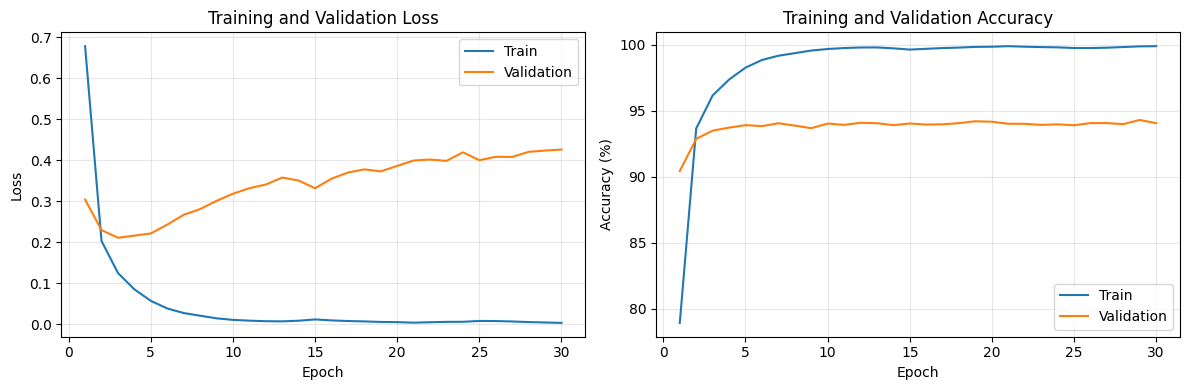

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, len(train_losses) + 1)

ax1.plot(epochs_range, train_losses, label='Train')
ax1.plot(epochs_range, val_losses, label='Validation')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, [a * 100 for a in train_accs], label='Train')
ax2.plot(epochs_range, [a * 100 for a in val_accs], label='Validation')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
model.load_state_dict(torch.load('best_pos_model.pt', weights_only=True))
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader)

print(f"Test accuracy: {test_acc:.2%}")
print(f"Test loss:     {test_loss:.4f}")

# per-tag accuracy breakdown
print(f"\n{'Tag':>6}  {'Correct':>8}  {'Total':>8}  {'Accuracy':>8}")
print("-" * 38)

tag_correct = Counter()
tag_total = Counter()
for pred, label in zip(test_preds, test_labels):
    tag_total[label] += 1
    if pred == label:
        tag_correct[label] += 1

for tag_idx in sorted(tag_total.keys()):
    tag = idx2tag[tag_idx]
    c = tag_correct[tag_idx]
    t = tag_total[tag_idx]
    print(f"{tag:>6}  {c:>8,}  {t:>8,}  {c/t:>8.2%}")

FileNotFoundError: [Errno 2] No such file or directory: 'best_pos_model.pt'

In [ ]:
from collections import defaultdict

confusion = defaultdict(Counter)
for pred, label in zip(test_preds, test_labels):
    pred_tag = idx2tag[pred]
    true_tag = idx2tag[label]
    if pred_tag != true_tag:
        confusion[true_tag][pred_tag] += 1

print("Most common confusions (true → predicted):\n")
all_confusions = []
for true_tag, preds in confusion.items():
    for pred_tag, count in preds.items():
        all_confusions.append((count, true_tag, pred_tag))

all_confusions.sort(reverse=True)
for count, true_tag, pred_tag in all_confusions[:15]:
    print(f"  {true_tag:>6} → {pred_tag:<6}  {count:>4} times")

In [ ]:
def tag_sentence(model, sentence):
    """Run POS tagging on a raw sentence string."""
    model.eval()
    tokens = re.findall(r"\w+|[^\w\s]", sentence)
    if not tokens:
        return []

    word_ids = [word2idx.get(t.lower(), UNK_IDX) for t in tokens]
    case_ids = [get_case_id(t) for t in tokens]
    suf_ids = [get_suffix_id(t) for t in tokens]

    word_ids_t = torch.tensor([word_ids], dtype=torch.long).to(device)
    case_ids_t = torch.tensor([case_ids], dtype=torch.long).to(device)
    suf_ids_t = torch.tensor([suf_ids], dtype=torch.long).to(device)

    with torch.no_grad():
        logits = model(word_ids_t, case_ids_t, suf_ids_t)
        preds = logits.argmax(dim=-1)[0]

    return [(tok, idx2tag[p.item()]) for tok, p in zip(tokens, preds)]

In [ ]:
def display_tags(results):
    colors = {
        "NOUN": "\033[94m", "PROPN": "\033[94m",
        "VERB": "\033[92m", "AUX": "\033[92m",
        "ADJ": "\033[93m",
        "ADV": "\033[95m",
        "DET": "\033[96m", "PRON": "\033[96m",
    }
    RESET = "\033[0m"

    parts = []
    for token, tag in results:
        color = colors.get(tag, "")
        parts.append(f"{color}{token}/{tag}{RESET}")
    print("  " + "  ".join(parts))

In [ ]:
test_sents = [
    "I run daily.",
    "I loved my morning run.",
    "The record player will record his voice if he can find a can.",
    "Google announced a new AI model yesterday in San Francisco.",
    "The woman who lives next door is walking her very energetic dog through the woods.",
    "Since they were leaving, the tired travelers had been checking their bags.",
]

for s in test_sents:
    print(f"\n\"{s}\"")
    display_tags(tag_sentence(model, s))